In [1]:
import pandas as pd
import numpy as np
import duckdb
from pathlib import Path

pd.set_option('display.max_columns', 60)

# Cargar dataset limpio del Día 1
df = pd.read_parquet(Path('../data/processed/clean_data.parquet'))

print(f"✅ Dataset cargado correctamente")
print(f"   Shape: {df.shape}")
print(f"   Clase positiva: {df['readmitted_binary'].mean()*100:.1f}%")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())

✅ Dataset cargado correctamente
   Shape: (99343, 52)
   Clase positiva: 11.4%

Columnas disponibles:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'readmitted_binary', 'payer_label']


In [2]:
# === ELIMINACIÓN DE COLUMNAS ===

# 1. Identificadores — no son predictores
drop_ids = ['encounter_id', 'patient_nbr']

# 2. Target original — ahora tenemos readmitted_binary
drop_target = ['readmitted']

# 3. Missingness extremo sin valor como flag
drop_missing = ['weight']  # 96.9% — inutilizable

# 4. Variables administrativas sin señal clínica
drop_admin = ['payer_code', 'payer_label']  # 39.6% missing, señal mínima

# 5. Fármacos eliminados por criterio farmacológico (Día 1)
drop_pharma = [
    'examide',        # nunca llegó a uso clínico
    'citoglipton',    # nunca llegó a uso clínico
    'troglitazone',   # retirado del mercado 2000 por hepatotoxicidad
    'acetohexamide',  # sulfonilurea 1ª gen obsoleta
    'tolbutamide',    # sulfonilurea 1ª gen obsoleta
    'chlorpropamide', # sulfonilurea 1ª gen obsoleta
    'tolazamide',     # sulfonilurea 1ª gen obsoleta
]

all_drops = drop_ids + drop_target + drop_missing + drop_admin + drop_pharma

df_clean = df.drop(columns=all_drops)

print(f"Columnas originales:  {df.shape[1]}")
print(f"Columnas eliminadas:  {len(all_drops)}")
print(f"Columnas restantes:   {df_clean.shape[1]}")
print(f"\nEliminadas:")
for col in all_drops:
    print(f"  - {col}")

Columnas originales:  52
Columnas eliminadas:  13
Columnas restantes:   39

Eliminadas:
  - encounter_id
  - patient_nbr
  - readmitted
  - weight
  - payer_code
  - payer_label
  - examide
  - citoglipton
  - troglitazone
  - acetohexamide
  - tolbutamide
  - chlorpropamide
  - tolazamide


In [3]:
# ===  FLAGS DE MISSINGNESS INFORMATIVO ===

# A1Cresult y max_glu_serum — missingness como señal clínica
df_clean['was_A1C_measured'] = df_clean['A1Cresult'].notna().astype(int)
df_clean['was_glucose_measured'] = df_clean['max_glu_serum'].notna().astype(int)

# Reemplazar NaN por 'Not_measured' para tratarlos como categoría explícita
df_clean['A1Cresult'] = df_clean['A1Cresult'].fillna('Not_measured')
df_clean['max_glu_serum'] = df_clean['max_glu_serum'].fillna('Not_measured')

# race — '?' como categoría explícita
df_clean['race'] = df_clean['race'].replace('?', 'Unknown')

# medical_specialty — '?' como categoría explícita (49.1% missing)
df_clean['medical_specialty'] = df_clean['medical_specialty'].replace('?', 'Unknown')

print("=== FLAGS DE MISSINGNESS ===")
print(f"was_A1C_measured=1:      {df_clean['was_A1C_measured'].sum():,} ({df_clean['was_A1C_measured'].mean()*100:.1f}%)")
print(f"was_glucose_measured=1:  {df_clean['was_glucose_measured'].sum():,} ({df_clean['was_glucose_measured'].mean()*100:.1f}%)")
print(f"\nA1Cresult categorías:    {df_clean['A1Cresult'].unique()}")
print(f"max_glu_serum categorías: {df_clean['max_glu_serum'].unique()}")

=== FLAGS DE MISSINGNESS ===
was_A1C_measured=1:      16,834 (16.9%)
was_glucose_measured=1:  5,152 (5.2%)

A1Cresult categorías:    ['Not_measured' '>7' '>8' 'Norm']
max_glu_serum categorías: ['Not_measured' '>300' 'Norm' '>200']


In [4]:
# === AGE A NUMÉRICO ===
# Convertir rangos a punto medio — decisión documentada en EDA

age_midpoint = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}

df_clean['age_numeric'] = df_clean['age'].map(age_midpoint)

print("=== AGE CONVERSION ===")
print(df_clean[['age', 'age_numeric']].drop_duplicates().sort_values('age_numeric'))
print(f"\nNaN en age_numeric: {df_clean['age_numeric'].isna().sum()}")

=== AGE CONVERSION ===
        age  age_numeric
0    [0-10)            5
1   [10-20)           15
2   [20-30)           25
3   [30-40)           35
4   [40-50)           45
5   [50-60)           55
6   [60-70)           65
7   [70-80)           75
8   [80-90)           85
9  [90-100)           95

NaN en age_numeric: 0


In [5]:
# === PARTE  — AGRUPACIÓN ICD-9 ===
# 9 categorías clínicas estándar (Clinical Classifications Software)
# Criterio clínico, no estadístico

def classify_icd9(code):
    if pd.isna(code) or code == '?':
        return 'Unknown'
    
    code = str(code).strip()
    
    # Códigos E y V — externos e información suplementaria
    if code.startswith('V'):
        return 'Supplementary'
    if code.startswith('E'):
        return 'External'
    
    try:
        num = float(code)
    except ValueError:
        return 'Unknown'
    
    if 1 <= num <= 139:   return 'Infectious'
    if 140 <= num <= 239:   return 'Neoplasms'
    if 240 <= num <= 279:
        if 250 <= num <= 250.99: return 'Diabetes'
        return 'Endocrine_Metabolic'
    if 280 <= num <= 289:   return 'Blood'
    if 290 <= num <= 319:   return 'Mental'
    if 320 <= num <= 389:   return 'Nervous'
    if 390 <= num <= 459:   return 'Circulatory'
    if 460 <= num <= 519:   return 'Respiratory'
    if 520 <= num <= 579:   return 'Digestive'
    if 580 <= num <= 629:   return 'Genitourinary'
    if 630 <= num <= 679:   return 'Pregnancy'
    if 680 <= num <= 709:   return 'Skin'
    if 710 <= num <= 739:   return 'Musculoskeletal'
    if 740 <= num <= 759:   return 'Congenital'
    if 760 <= num <= 779:   return 'Perinatal'
    if 780 <= num <= 799:   return 'Symptoms'
    if 800 <= num <= 999:   return 'Injury'
    
    return 'Other'

# Aplicar a los tres diagnósticos
for diag in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[f'{diag}_cat'] = df_clean[diag].apply(classify_icd9)

print("=== DISTRIBUCIÓN DIAGNÓSTICO PRIMARIO ===")
print(df_clean['diag_1_cat'].value_counts())
print(f"\nCategorías únicas: {df_clean['diag_1_cat'].nunique()}")

=== DISTRIBUCIÓN DIAGNÓSTICO PRIMARIO ===
diag_1_cat
Circulatory            29585
Respiratory             9919
Digestive               9072
Diabetes                8661
Symptoms                7601
Injury                  6853
Genitourinary           4963
Musculoskeletal         4935
Neoplasms               3131
Endocrine_Metabolic     2643
Infectious              2553
Skin                    2508
Mental                  2256
Supplementary           1632
Nervous                 1181
Blood                   1092
Pregnancy                687
Congenital                50
Unknown                   20
External                   1
Name: count, dtype: int64

Categorías únicas: 20


In [6]:
# ===  FEATURE ENGINEERING ===

# 1. Utilización previa total
df_clean['total_prior_visits'] = (df_clean['number_outpatient'] + 
                                   df_clean['number_emergency'] + 
                                   df_clean['number_inpatient'])

# 2. Intensidad diagnóstica por día
df_clean['lab_intensity'] = (df_clean['num_lab_procedures'] / 
                              df_clean['time_in_hospital'])

# 3. Conteo de medicamentos cambiados (excluyendo insulina y metformina)
change_cols = ['repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 
               'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 
               'miglitol', 'glyburide-metformin', 'glipizide-metformin',
               'glimepiride-pioglitazone', 'metformin-rosiglitazone', 
               'metformin-pioglitazone']

df_clean['n_meds_changed'] = df_clean[change_cols].isin(['Up', 'Down']).sum(axis=1)

# 4. Flag diabetes como diagnóstico primario
df_clean['diabetes_as_primary'] = (df_clean['diag_1_cat'] == 'Diabetes').astype(int)

print("=== FEATURES NUEVOS ===")
print(f"total_prior_visits  — media: {df_clean['total_prior_visits'].mean():.2f}, "
      f"max: {df_clean['total_prior_visits'].max()}")
print(f"lab_intensity       — media: {df_clean['lab_intensity'].mean():.2f}, "
      f"max: {df_clean['lab_intensity'].max():.1f}")
print(f"n_meds_changed      — distribución:")
print(df_clean['n_meds_changed'].value_counts().sort_index())
print(f"\ndiabetes_as_primary=1: {df_clean['diabetes_as_primary'].sum():,} "
      f"({df_clean['diabetes_as_primary'].mean()*100:.1f}%)")

=== FEATURES NUEVOS ===
total_prior_visits  — media: 1.20, max: 80
lab_intensity       — media: 14.32, max: 92.0
n_meds_changed      — distribución:
n_meds_changed
0    95427
1     3825
2       90
3        1
Name: count, dtype: int64

diabetes_as_primary=1: 8,661 (8.7%)


In [7]:
# === RESUMEN DEL DATASET PROCESADO ===
print(f"Shape final: {df_clean.shape}")
print(f"\nColumnas finales ({df_clean.shape[1]}):")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:2}. {col}")

print(f"\n=== VERIFICACIÓN DE MISSINGNESS RESIDUAL ===")
missing = df_clean.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("✅ Sin NaN residuales")
else:
    print(missing)

# Guardar
df_clean.to_parquet(Path('../data/processed/features.parquet'), index=False)
print(f"\n✅ features.parquet guardado — {df_clean.shape}")

Shape final: (99343, 49)

Columnas finales (49):
   1. race
   2. gender
   3. age
   4. admission_type_id
   5. discharge_disposition_id
   6. admission_source_id
   7. time_in_hospital
   8. medical_specialty
   9. num_lab_procedures
  10. num_procedures
  11. num_medications
  12. number_outpatient
  13. number_emergency
  14. number_inpatient
  15. diag_1
  16. diag_2
  17. diag_3
  18. number_diagnoses
  19. max_glu_serum
  20. A1Cresult
  21. metformin
  22. repaglinide
  23. nateglinide
  24. glimepiride
  25. glipizide
  26. glyburide
  27. pioglitazone
  28. rosiglitazone
  29. acarbose
  30. miglitol
  31. insulin
  32. glyburide-metformin
  33. glipizide-metformin
  34. glimepiride-pioglitazone
  35. metformin-rosiglitazone
  36. metformin-pioglitazone
  37. change
  38. diabetesMed
  39. readmitted_binary
  40. was_A1C_measured
  41. was_glucose_measured
  42. age_numeric
  43. diag_1_cat
  44. diag_2_cat
  45. diag_3_cat
  46. total_prior_visits
  47. lab_intensity
  48. n

## Resumen de Limpieza — Decisiones Aplicadas

**Columnas eliminadas (13):**
- Identificadores: `encounter_id`, `patient_nbr`
- Target original: `readmitted` (reemplazado por `readmitted_binary`)
- Missingness extremo: `weight` (96.9%)
- Administrativas sin señal: `payer_code`, `payer_label`
- Farmacológicas obsoletas/sin uso: `examide`, `citoglipton`, 
  `troglitazone`, `acetohexamide`, `tolbutamide`, `chlorpropamide`, `tolazamide`

**Features nuevos creados (10):**
- `was_A1C_measured`, `was_glucose_measured` — missingness informativo
- `age_numeric` — punto medio del rango etario
- `diag_1_cat`, `diag_2_cat`, `diag_3_cat` — ICD-9 agrupado en 20 categorías clínicas
- `total_prior_visits` — utilización histórica del sistema
- `lab_intensity` — procedimientos de laboratorio por día de internación
- `n_meds_changed` — cambios en medicación secundaria (excl. insulina y metformina)
- `diabetes_as_primary` — flag diagnóstico primario diabético

**Missingness residual: 0**

In [8]:
# === SETUP DUCKDB ===
import duckdb

# DuckDB puede queryear dataframes de pandas directamente
con = duckdb.connect()
con.register('encounters', df_clean)

# Test
result = con.execute("SELECT COUNT(*) as total FROM encounters").fetchdf()
print(f"✅ DuckDB conectado — {result['total'][0]:,} registros disponibles")

✅ DuckDB conectado — 99,343 registros disponibles


# Query 1 — ¿Más historia hospitalaria implica más riesgo?


In [9]:
# === QUERY 1 — Readmisión por internaciones previas ===
q1 = """
SELECT 
    number_inpatient,
    COUNT(*) as n_encounters,
    SUM(readmitted_binary) as n_readmitted,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(time_in_hospital), 1) as avg_stay_days
FROM encounters
WHERE number_inpatient <= 10
GROUP BY number_inpatient
ORDER BY number_inpatient
"""

q1_result = con.execute(q1).fetchdf()
print(q1_result.to_string(index=False))

 number_inpatient  n_encounters  n_readmitted  readmission_rate_pct  avg_stay_days
                0         66245        5690.0                   8.6            4.2
                1         18984        2516.0                  13.3            4.7
                2          7300        1309.0                  17.9            4.8
                3          3271         688.0                  21.0            4.9
                4          1574         380.0                  24.1            5.1
                5           791         253.0                  32.0            4.9
                6           474         165.0                  34.8            5.0
                7           262          95.0                  36.3            5.0
                8           145          67.0                  46.2            4.8
                9           109          47.0                  43.1            4.6
               10            59          26.0                  44.1            4.9


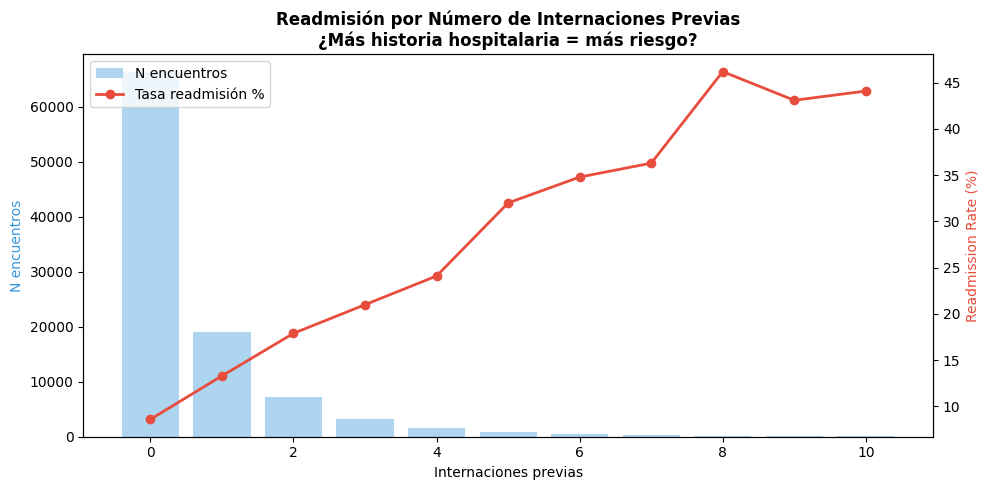

In [10]:
# Visualización Q1
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(q1_result['number_inpatient'], q1_result['n_encounters'],
        color='#3498db', alpha=0.4, label='N encuentros')
ax1.set_xlabel('Internaciones previas')
ax1.set_ylabel('N encuentros', color='#3498db')

ax2 = ax1.twinx()
ax2.plot(q1_result['number_inpatient'], q1_result['readmission_rate_pct'],
         color='#e74c3c', marker='o', linewidth=2, label='Tasa readmisión %')
ax2.set_ylabel('Readmission Rate (%)', color='#e74c3c')

ax1.set_title('Readmisión por Número de Internaciones Previas\n'
              '¿Más historia hospitalaria = más riesgo?', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../data/processed/sql_q1_inpatient.png', dpi=150)
plt.show()

### Query 1 — Readmisión por Internaciones Previas

**Gradiente: 8.6% → 46.2%**

Cada internación previa adicional aumenta el riesgo de readmisión temprana.
Pacientes con 0 internaciones previas: 8.6% de readmisión.
Pacientes con 8+ internaciones previas: >44% de readmisión — 5x el baseline.

**Hallazgo clave:** `number_inpatient` no es solo un predictor —
es el marcador más potente de fragilidad sistémica en este dataset.
Captura historia de descompensación recurrente que ninguna variable
clínica puntual puede reemplazar.

**Nota:** `avg_stay_days` es casi constante (~4.8 días) en todos los grupos —
la severidad de cada episodio individual no aumenta con la historia,
pero la probabilidad de volver sí. El problema es sistémico, no episódico.

# Query 2 — ¿La duración de internación predice readmisión?


In [11]:
q2 = """
SELECT 
    time_in_hospital,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(num_medications), 1) as avg_medications,
    ROUND(AVG(number_diagnoses), 1) as avg_diagnoses
FROM encounters
GROUP BY time_in_hospital
ORDER BY time_in_hospital
"""

q2_result = con.execute(q2).fetchdf()
print(q2_result.to_string(index=False))

 time_in_hospital  n_encounters  readmission_rate_pct  avg_medications  avg_diagnoses
                1         13824                   8.4             11.1            6.6
                2         16891                  10.1             12.5            7.0
                3         17432                  10.8             14.3            7.3
                4         13684                  12.0             16.0            7.5
                5          9749                  12.3             17.5            7.7
                6          7355                  12.9             18.6            7.8
                7          5696                  13.1             19.9            7.9
                8          4271                  14.6             21.1            7.9
                9          2879                  14.3             22.0            8.0
               10          2262                  14.8             23.1            8.1
               11          1770                  10.8 

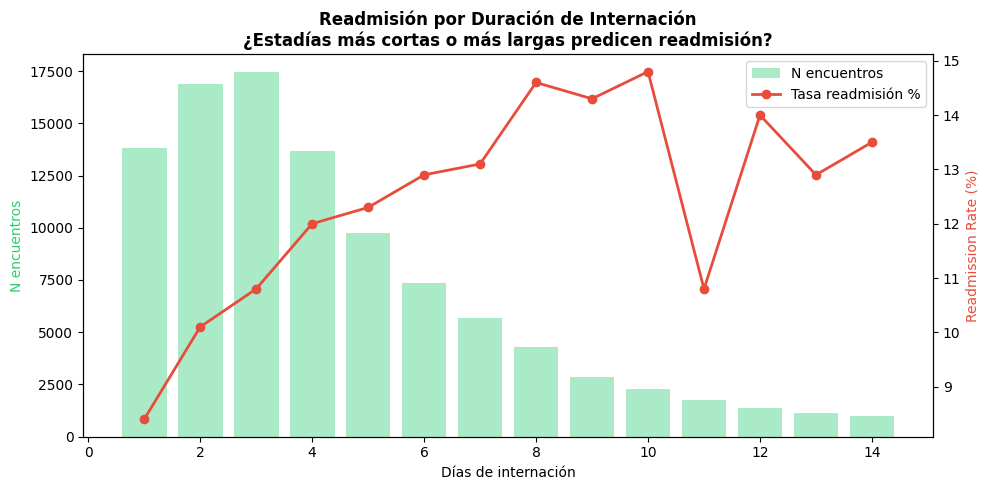

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(q2_result['time_in_hospital'], q2_result['n_encounters'],
        color='#2ecc71', alpha=0.4, label='N encuentros')
ax1.set_xlabel('Días de internación')
ax1.set_ylabel('N encuentros', color='#2ecc71')

ax2 = ax1.twinx()
ax2.plot(q2_result['time_in_hospital'], q2_result['readmission_rate_pct'],
         color='#e74c3c', marker='o', linewidth=2, label='Tasa readmisión %')
ax2.set_ylabel('Readmission Rate (%)', color='#e74c3c')

ax1.set_title('Readmisión por Duración de Internación\n'
              '¿Estadías más cortas o más largas predicen readmisión?', 
              fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('../data/processed/sql_q2_stay.png', dpi=150)
plt.show()

### Query 2 — Readmisión por Duración de Internación

**Patrón: estadías más largas = más readmisión (hasta día 10)**
- 1 día: 8.4% → 10 días: 14.8% — tendencia ascendente clara
- Día 11: caída a 10.8% — probablemente selección de casos complejos
  que requieren internación prolongada pero se estabilizan mejor

**Interpretación clínica:**
Estadías largas reflejan mayor severidad y complejidad clínica
(avg_medications sube de 11 a 25, avg_diagnoses de 6.6 a 8.2).
Estos pacientes tienen más comorbilidades activas al alta —
mayor riesgo de descompensación temprana.

**Estadías cortas (1-2 días) no son necesariamente seguras:**
8.4% en 1 día puede reflejar altas prematuras o casos leves genuinos.
Sin información de severidad al ingreso, no es distinguible.

**Implicación para features:**
`time_in_hospital` tiene señal pero no lineal pura —
la combinación con `num_medications` y `number_diagnoses`
captura mejor la complejidad que cada variable sola.
Esto justifica `lab_intensity` como feature sintético.

In [13]:
q3 = """
SELECT 
    diag_1_cat,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(time_in_hospital), 1) as avg_stay,
    ROUND(AVG(num_medications), 1) as avg_meds
FROM encounters
WHERE diag_1_cat NOT IN ('Unknown', 'External', 'Supplementary')
GROUP BY diag_1_cat
HAVING COUNT(*) > 200
ORDER BY readmission_rate_pct DESC
"""

q3_result = con.execute(q3).fetchdf()
print(q3_result.to_string(index=False))

         diag_1_cat  n_encounters  readmission_rate_pct  avg_stay  avg_meds
              Blood          1092                  13.6       4.0      13.5
           Diabetes          8661                  13.1       4.3      14.0
             Injury          6853                  12.4       4.6      17.3
         Infectious          2553                  12.3       5.4      16.8
Endocrine_Metabolic          2643                  12.3       3.7      13.6
             Mental          2256                  12.2       5.9      12.0
        Circulatory         29585                  11.7       4.2      17.1
        Respiratory          9919                  11.2       5.0      17.9
      Genitourinary          4963                  11.0       4.2      15.0
          Neoplasms          3131                  10.9       5.3      17.6
          Digestive          9072                  10.6       4.4      14.8
            Nervous          1181                  10.6       4.5      13.6
            

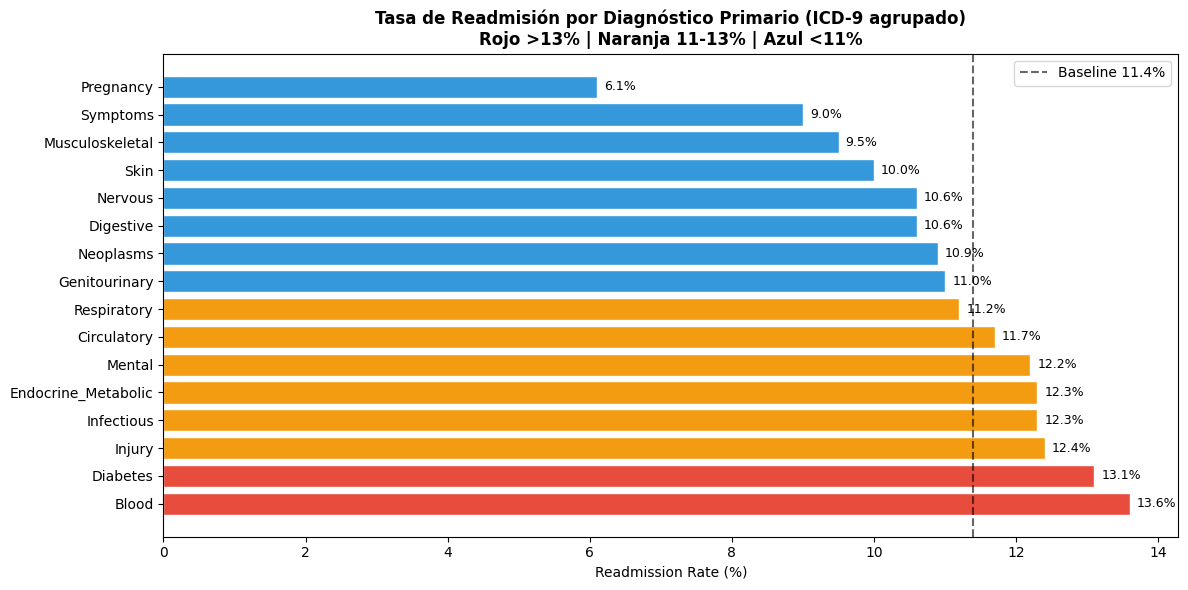

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#e74c3c' if r > 13 else '#f39c12' if r > 11 else '#3498db' 
          for r in q3_result['readmission_rate_pct']]

bars = ax.barh(q3_result['diag_1_cat'], q3_result['readmission_rate_pct'],
               color=colors, edgecolor='white')
ax.axvline(x=df_clean['readmitted_binary'].mean()*100, 
           color='black', linestyle='--', alpha=0.6, label='Baseline 11.4%')

for bar, val in zip(bars, q3_result['readmission_rate_pct']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)

ax.set_xlabel('Readmission Rate (%)')
ax.set_title('Tasa de Readmisión por Diagnóstico Primario (ICD-9 agrupado)\n'
             'Rojo >13% | Naranja 11-13% | Azul <11%', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/sql_q3_diagnosis.png', dpi=150)
plt.show()

### Query 3 — Readmisión por Diagnóstico Primario (ICD-9 agrupado)

**Grupos de mayor riesgo (>13%):**
- `Blood` 13.6% — anemias y coagulopatías: condiciones crónicas de difícil
  estabilización, frecuentemente secundarias a otras patologías subyacentes
- `Diabetes` 13.1% — cuando la diabetes es el diagnóstico PRIMARIO
  (no comorbilidad), el descontrol metabólico es el problema central.
  Mayor riesgo de readmisión por inestabilidad glucémica post-alta.

**Hallazgo contraintuitivo — Circulatory solo 11.7%:**
A pesar de ser el grupo más numeroso (29,585 encuentros), no tiene
la tasa más alta. Los protocolos de manejo cardiovascular post-alta
(medicación, seguimiento) están más estandarizados que en otros grupos.

**Pregnancy 6.1% — tasa más baja:**
Coherente — pacientes más jóvenes, episodios más acotados,
seguimiento post-alta más estructurado.

**Symptoms 9.0% con avg_stay=2.8 días:**
Internaciones cortas por síntomas inespecíficos — posiblemente
casos leves o diagnósticos aún no definidos al alta.

**Implicación:** `diag_1_cat` es un feature con señal real —
rango de 6.1% a 13.6% entre categorías. La agrupación ICD-9
fue la decisión correcta vs. one-hot de 900 categorías.

# Query 4 — ¿La polifarmacia predice readmisión?


In [15]:
q4 = """
SELECT 
    CASE 
        WHEN num_medications <= 5  THEN '1-5 meds'
        WHEN num_medications <= 10 THEN '6-10 meds'
        WHEN num_medications <= 15 THEN '11-15 meds'
        WHEN num_medications <= 20 THEN '16-20 meds'
        WHEN num_medications <= 25 THEN '21-25 meds'
        ELSE '26+ meds'
    END as med_group,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(num_medications), 1) as avg_meds,
    ROUND(AVG(time_in_hospital), 1) as avg_stay
FROM encounters
GROUP BY med_group
ORDER BY avg_meds
"""

q4_result = con.execute(q4).fetchdf()
print(q4_result.to_string(index=False))

 med_group  n_encounters  readmission_rate_pct  avg_meds  avg_stay
  1-5 meds          4938                   7.6       3.9       2.3
 6-10 meds         20374                   9.6       8.3       3.0
11-15 meds         28846                  11.1      13.0       3.8
16-20 meds         22096                  12.4      17.8       4.7
21-25 meds         12161                  13.3      22.7       5.7
  26+ meds         10928                  13.0      32.4       7.3


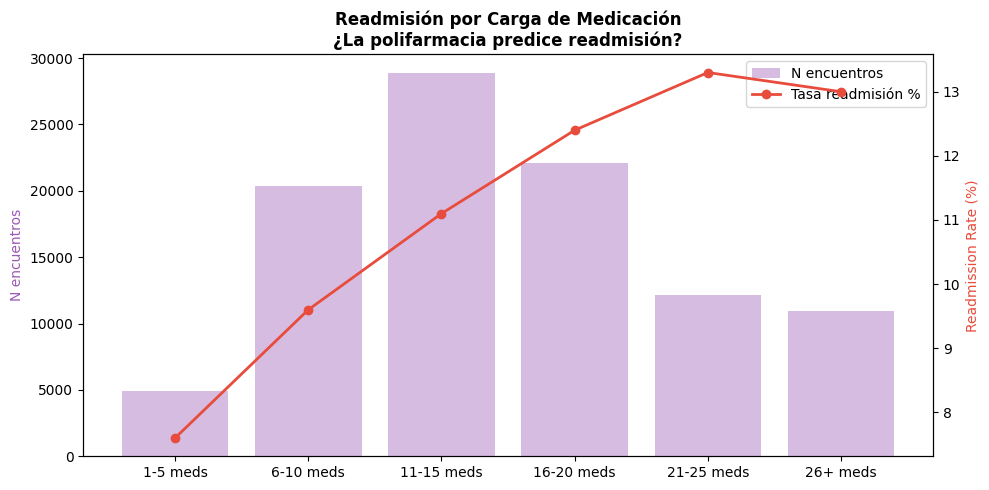

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(q4_result['med_group'], q4_result['n_encounters'],
        color='#9b59b6', alpha=0.4, label='N encuentros')
ax1.set_ylabel('N encuentros', color='#9b59b6')

ax2 = ax1.twinx()
ax2.plot(q4_result['med_group'], q4_result['readmission_rate_pct'],
         color='#e74c3c', marker='o', linewidth=2, label='Tasa readmisión %')
ax2.set_ylabel('Readmission Rate (%)', color='#e74c3c')

ax1.set_title('Readmisión por Carga de Medicación\n'
              '¿La polifarmacia predice readmisión?', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.savefig('../data/processed/sql_q4_polypharmacy.png', dpi=150)
plt.show()

### Query 4 — Polifarmacia y Readmisión

**Gradiente monótono: 7.6% → 13.3%**
- 1-5 meds: 7.6% — pacientes con manejo simple, estadía 2.3 días
- 21-25 meds: 13.3% — casi el doble de riesgo, estadía 5.7 días
- 26+ meds: 13.0% — se estabiliza, posiblemente casos muy complejos
  con mejor seguimiento post-alta por su severidad conocida

**Interpretación clínica:**
`num_medications` es proxy de complejidad clínica global, no solo
de tratamiento diabético. Un paciente con 25 medicamentos tiene
múltiples comorbilidades activas simultáneas — cada una es un
vector potencial de descompensación post-alta.

**Correlación con estadía:** avg_stay sube de 2.3 a 7.3 días
en paralelo con medicación — ambas variables capturan severidad,
lo que explica su correlación de 0.46 vista en el EDA.

In [17]:
q5 = """
SELECT 
    discharge_disposition_id,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(time_in_hospital), 1) as avg_stay
FROM encounters
GROUP BY discharge_disposition_id
HAVING COUNT(*) > 300
ORDER BY readmission_rate_pct DESC
"""

q5_result = con.execute(q5).fetchdf()

# Agregar etiquetas legibles
discharge_labels = {
    1: 'Home', 2: 'Short term hospital', 3: 'SNF',
    4: 'ICF', 5: 'Other inpatient', 6: 'Home health service',
    7: 'Left AMA', 8: 'Home IV provider', 9: 'Inpatient readmit',
    15: 'Swing bed', 16: 'Outpatient referral', 17: 'Outpatient this inst',
    22: 'Rehab facility', 23: 'Long term care', 24: 'Medicaid nursing',
    25: 'Not Mapped', 27: 'Federal facility', 28: 'Psychiatric',
    29: 'Critical Access Hospital', 30: 'Other institution'
}

q5_result['discharge_label'] = q5_result['discharge_disposition_id'].map(
    discharge_labels).fillna('Other')
q5_result = q5_result.sort_values('readmission_rate_pct', ascending=True)

print(q5_result[['discharge_label', 'n_encounters', 
                  'readmission_rate_pct', 'avg_stay']].to_string(index=False))

    discharge_label  n_encounters  readmission_rate_pct  avg_stay
     Long term care           412                   7.3       7.1
         Not Mapped           989                   9.3       4.3
               Home         60234                   9.3       3.7
              Other          3691                  12.4       5.2
Home health service         12902                  12.7       5.4
                ICF           815                  12.8       5.4
           Left AMA           623                  14.4       2.8
                SNF         13954                  14.7       5.8
Short term hospital          2128                  16.1       3.9
    Other inpatient          1184                  20.9       5.7
     Rehab facility          1993                  27.7       5.8


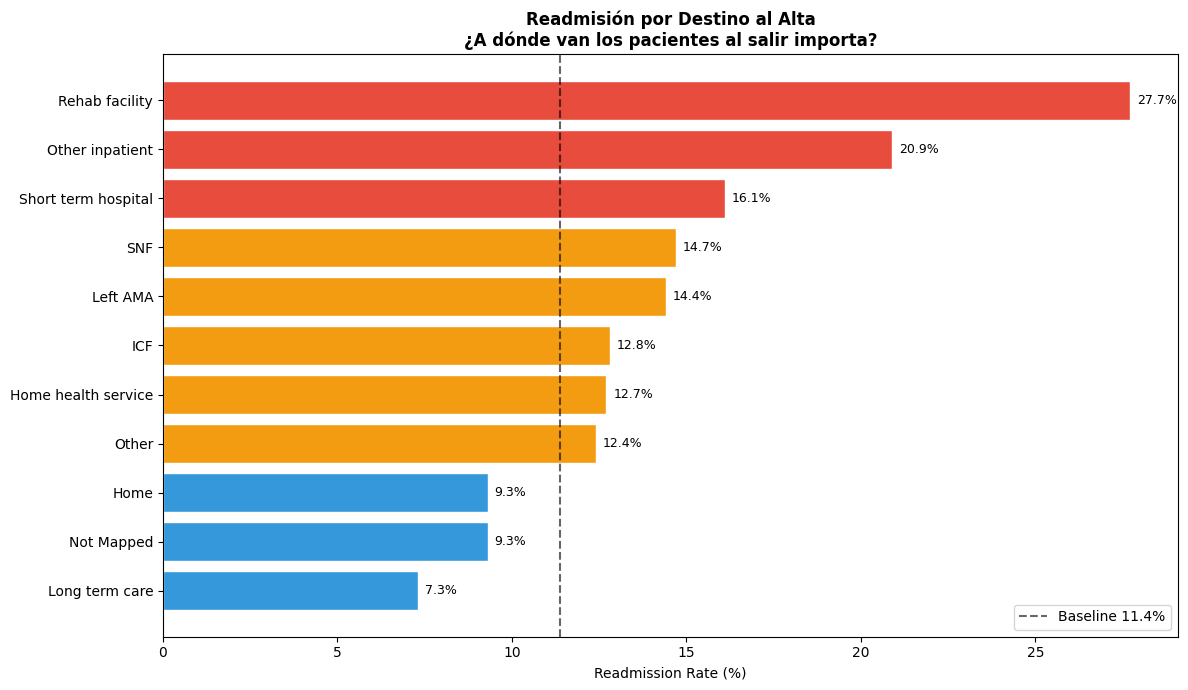

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#e74c3c' if r > 15 else '#f39c12' if r > 11 else '#3498db'
          for r in q5_result['readmission_rate_pct']]

bars = ax.barh(q5_result['discharge_label'], 
               q5_result['readmission_rate_pct'],
               color=colors, edgecolor='white')

ax.axvline(x=df_clean['readmitted_binary'].mean()*100,
           color='black', linestyle='--', alpha=0.6, label='Baseline 11.4%')

for bar, val in zip(bars, q5_result['readmission_rate_pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)

ax.set_xlabel('Readmission Rate (%)')
ax.set_title('Readmisión por Destino al Alta\n'
             '¿A dónde van los pacientes al salir importa?', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/sql_q5_discharge.png', dpi=150)
plt.show()

### Query 5 — Destino al Alta

**Rango extremo: 7.3% → 27.7%**
La variable `discharge_disposition_id` tiene el mayor rango de tasas
de readmisión de todas las variables categóricas analizadas.

**Hallazgos clave:**

`Rehab facility` 27.7% — el más alto. Pacientes transferidos a
rehabilitación tienen alta complejidad funcional post-episodio agudo.
La readmisión frecuente refleja fragilidad subyacente, no falla de la rehab.

`Other inpatient` 20.9% y `Short term hospital` 16.1% —
transferencias entre instituciones indican casos que no pudieron
estabilizarse en el hospital original. Mayor complejidad, mayor riesgo.

`Left AMA` 14.4% (Against Medical Advice) — pacientes que se van
sin completar el tratamiento recomendado. Readmisión elevada coherente
con alta prematura y posible barrera de acceso o desconfianza institucional.

`SNF` 14.7% (Skilled Nursing Facility) — adultos mayores frágiles
transferidos a enfermería especializada. Población de alto riesgo basal.

`Home` 9.3% — el destino más común (60,234 encuentros = 60% del dataset)
tiene tasa por debajo del baseline. Pacientes dados de alta a domicilio
son los más estables clínicamente.

`Long term care` 7.3% — paradójicamente el más bajo. Pacientes en
cuidado prolongado tienen seguimiento continuo — la readmisión
al hospital agudo es menos probable porque están institucionalizados.

**Implicación para features:**
`discharge_disposition_id` es una variable de alta señal predictiva.
Requiere encoding cuidadoso — no es ordinal, las categorías tienen
significado clínico heterogéneo.

In [19]:
q6_biotec = """
SELECT 
    insulin,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    -- ¿El ajuste de insulina se correlaciona con control glucémico?
    ROUND(SUM(CASE WHEN A1Cresult = '>8' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_A1C_gt8,
    ROUND(SUM(CASE WHEN A1Cresult = '>7' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_A1C_gt7,
    ROUND(SUM(CASE WHEN was_A1C_measured = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_A1C_measured,
    -- ¿Qué tan descompensados llegan estos pacientes?
    ROUND(AVG(num_medications), 1) as avg_meds,
    ROUND(AVG(time_in_hospital), 1) as avg_stay,
    ROUND(AVG(number_diagnoses), 1) as avg_diagnoses,
    -- ¿Cuántos venían de emergencias previas?
    ROUND(AVG(number_emergency), 2) as avg_prior_emergency,
    -- ¿Cambiaron otros medicamentos junto con la insulina?
    ROUND(AVG(n_meds_changed), 2) as avg_other_meds_changed
FROM encounters
GROUP BY insulin
ORDER BY readmission_rate_pct DESC
"""

q6_result = con.execute(q6_biotec).fetchdf()
print(q6_result.to_string(index=False))

insulin  n_encounters  readmission_rate_pct  pct_A1C_gt8  pct_A1C_gt7  pct_A1C_measured  avg_meds  avg_stay  avg_diagnoses  avg_prior_emergency  avg_other_meds_changed
   Down         11908                  14.2         13.3          3.7              22.0      19.0       4.9            7.7                 0.29                    0.04
     Up         10987                  13.3         15.1          4.3              24.0      19.5       5.2            7.8                 0.35                    0.04
 Steady         30069                  11.4          9.0          4.0              18.1      16.2       4.4            7.4                 0.17                    0.04
     No         46379                  10.2          4.7          3.6              13.2      14.2       4.1            7.2                 0.16                    0.04


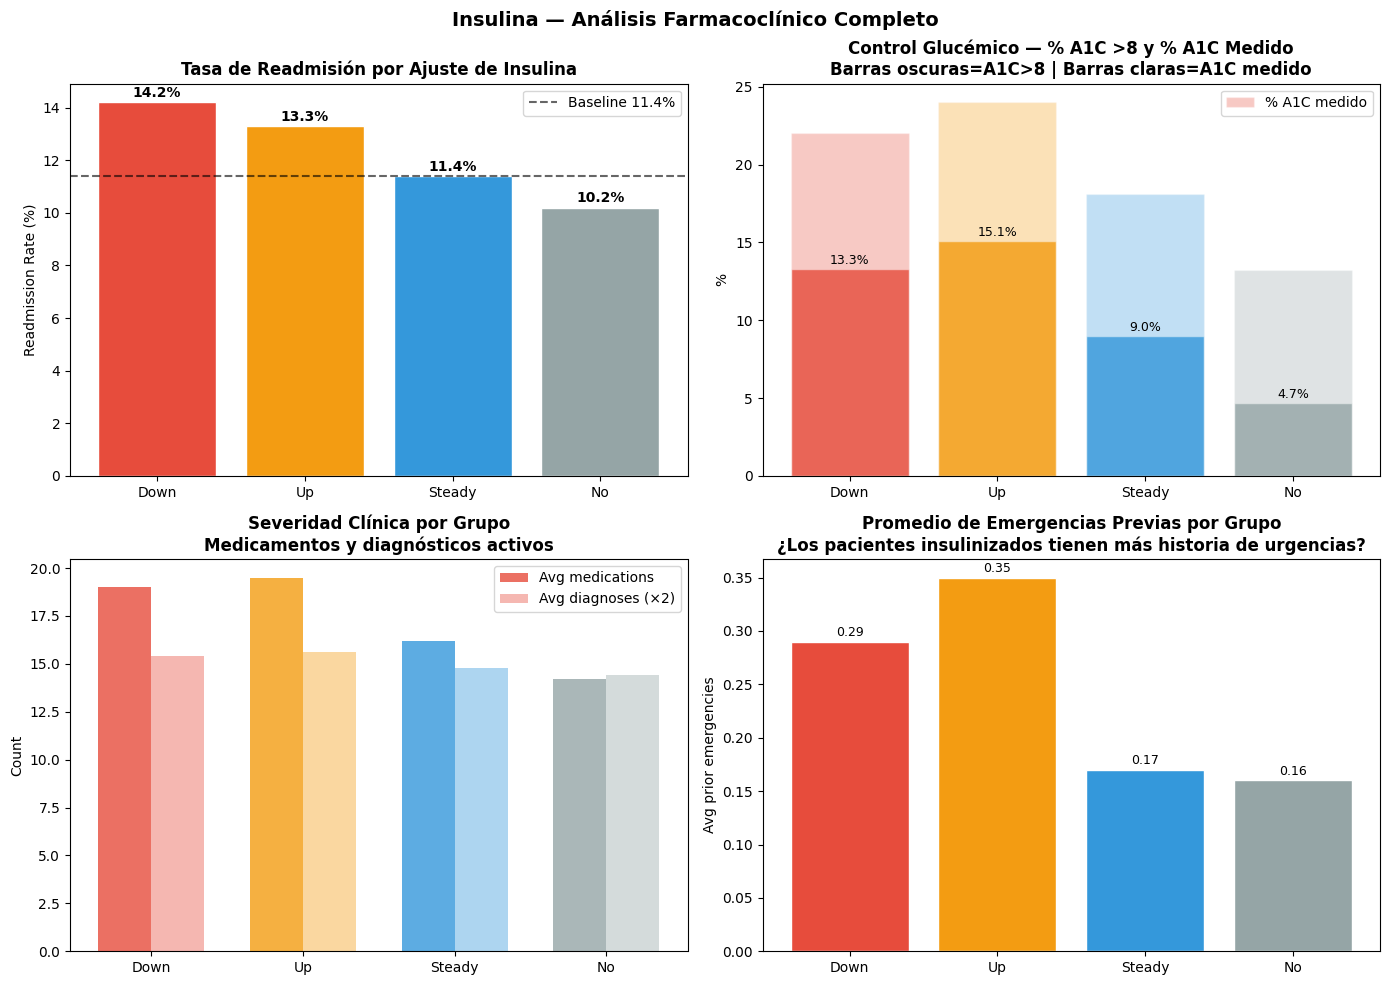

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors_insulin = {'Down': '#e74c3c', 'Up': '#f39c12', 
                  'Steady': '#3498db', 'No': '#95a5a6'}
bar_colors = [colors_insulin[v] for v in q6_result['insulin']]

# Plot 1 — Tasa de readmisión
axes[0,0].bar(q6_result['insulin'], q6_result['readmission_rate_pct'],
              color=bar_colors, edgecolor='white')
axes[0,0].axhline(y=df_clean['readmitted_binary'].mean()*100,
                  color='black', linestyle='--', alpha=0.6, label='Baseline 11.4%')
axes[0,0].set_title('Tasa de Readmisión por Ajuste de Insulina', fontweight='bold')
axes[0,0].set_ylabel('Readmission Rate (%)')
axes[0,0].legend()
for i, val in enumerate(q6_result['readmission_rate_pct']):
    axes[0,0].text(i, val + 0.2, f'{val}%', ha='center', fontweight='bold')

# Plot 2 — Control glucémico (A1C >8) por grupo
axes[0,1].bar(q6_result['insulin'], q6_result['pct_A1C_gt8'],
              color=bar_colors, edgecolor='white', alpha=0.8)
axes[0,1].bar(q6_result['insulin'], q6_result['pct_A1C_measured'],
              color=bar_colors, edgecolor='white', alpha=0.3, label='% A1C medido')
axes[0,1].set_title('Control Glucémico — % A1C >8 y % A1C Medido\n'
                    'Barras oscuras=A1C>8 | Barras claras=A1C medido', 
                    fontweight='bold')
axes[0,1].set_ylabel('%')
axes[0,1].legend()
for i, val in enumerate(q6_result['pct_A1C_gt8']):
    axes[0,1].text(i, val + 0.3, f'{val}%', ha='center', fontsize=9)

# Plot 3 — Severidad clínica
x = range(len(q6_result))
width = 0.35
axes[1,0].bar([xi - width/2 for xi in x], q6_result['avg_meds'],
              width, color=bar_colors, alpha=0.8, label='Avg medications')
axes[1,0].bar([xi + width/2 for xi in x], 
              q6_result['avg_diagnoses'] * 2,  # escalar para visibilidad
              width, color=bar_colors, alpha=0.4, label='Avg diagnoses (×2)')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(q6_result['insulin'])
axes[1,0].set_title('Severidad Clínica por Grupo\n'
                    'Medicamentos y diagnósticos activos', fontweight='bold')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Plot 4 — Emergencias previas
axes[1,1].bar(q6_result['insulin'], q6_result['avg_prior_emergency'],
              color=bar_colors, edgecolor='white')
axes[1,1].set_title('Promedio de Emergencias Previas por Grupo\n'
                    '¿Los pacientes insulinizados tienen más historia de urgencias?', 
                    fontweight='bold')
axes[1,1].set_ylabel('Avg prior emergencies')
for i, val in enumerate(q6_result['avg_prior_emergency']):
    axes[1,1].text(i, val + 0.005, f'{val:.2f}', ha='center', fontsize=9)

plt.suptitle('Insulina — Análisis Farmacoclínico Completo', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/sql_q6_insulin_biotec.png', dpi=150)
plt.show()

### Query 6 — Insulina: Análisis Farmacoclínico

**Pregunta central:** ¿El ajuste de insulina durante la internación
refleja decisión terapéutica óptima o respuesta a descompensación?

**Hallazgo principal — causalidad inversa evidente:**
Los grupos con ajuste de insulina (Up/Down) tienen mayor severidad
de entrada (más medicamentos, más diagnósticos, más emergencias previas)
que los grupos Steady/No. La insulina no causa readmisión —
los pacientes más graves reciben ajustes de insulina Y se readmiten más.
Esto es confusión por indicación clásica en datos observacionales.

**insulin Down (14.2% readmisión) — el patrón más preocupante:**
- A1C >8 en 13.3% — mal control glucémico al momento de reducir dosis
- Hipótesis: reducción de dosis por hipoglucemias durante internación,
  no por estabilización real. El paciente sale con dosis subóptima
  para su nivel de descontrol metabólico.
- 0.29 emergencias previas — historia de urgencias moderada

**insulin Up (13.3%) — severidad de entrada alta:**
- A1C >8 más frecuente (15.1%) y más medido (24%) — estos son los
  pacientes donde el médico decide insulinizar porque el descontrol
  es evidente y documentado
- 0.35 emergencias previas — la mayor historia de urgencias del grupo
- Mayor readmisión refleja complejidad basal, no efecto de la insulina

**insulin Steady (11.4%) — en baseline:**
- A1C >8 solo 9% — mejor control relativo
- Manejo estable = paciente más controlado = menor riesgo

**insulin No (10.2%) — menor riesgo:**
- Solo 4.7% con A1C >8 y solo 13.2% con A1C medido
- Pacientes manejados sin insulina tienen perfil metabólico más leve

**Advertencia metodológica crítica:**
Este análisis NO permite concluir que "bajar insulina causa readmisión".
La asignación de tratamiento es confundida por severidad — exactamente
el escenario donde inferencia causal requeriría un diseño experimental.
SHAP mostrará insulina como feature importante, pero no es intervenable
sin riesgo de razonamiento inverso.

In [21]:
q7 = """
WITH patient_encounters AS (
    SELECT 
        total_prior_visits,
        COUNT(*) as n_encounters,
        ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
        ROUND(AVG(num_medications), 1) as avg_meds,
        ROUND(AVG(time_in_hospital), 1) as avg_stay,
        ROUND(AVG(number_diagnoses), 1) as avg_diagnoses
    FROM encounters
    WHERE total_prior_visits <= 15
    GROUP BY total_prior_visits
)
SELECT * FROM patient_encounters
ORDER BY total_prior_visits
"""

q7_result = con.execute(q7).fetchdf()
print(q7_result.to_string(index=False))

 total_prior_visits  n_encounters  readmission_rate_pct  avg_meds  avg_stay  avg_diagnoses
                  0         54676                   8.3      15.5       4.2            7.1
                  1         19454                  11.8      16.1       4.5            7.6
                  2          9753                  15.0      16.6       4.6            7.7
                  3          5698                  15.7      16.8       4.6            7.9
                  4          3447                  17.6      17.0       4.6            8.0
                  5          1991                  18.7      17.3       4.6            8.0
                  6          1275                  23.8      17.4       4.5            7.9
                  7           849                  23.1      17.4       4.8            8.1
                  8           543                  25.0      18.0       4.5            8.1
                  9           423                  27.9      17.9       4.8            8.2

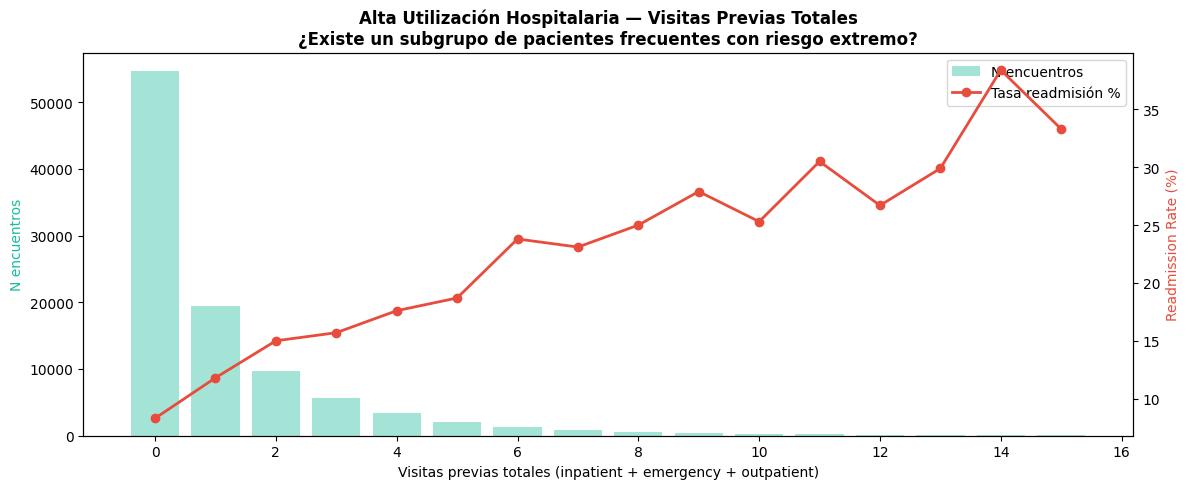

In [22]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(q7_result['total_prior_visits'], q7_result['n_encounters'],
        color='#1abc9c', alpha=0.4, label='N encuentros')
ax1.set_xlabel('Visitas previas totales (inpatient + emergency + outpatient)')
ax1.set_ylabel('N encuentros', color='#1abc9c')

ax2 = ax1.twinx()
ax2.plot(q7_result['total_prior_visits'], q7_result['readmission_rate_pct'],
         color='#e74c3c', marker='o', linewidth=2, label='Tasa readmisión %')
ax2.set_ylabel('Readmission Rate (%)', color='#e74c3c')

ax1.set_title('Alta Utilización Hospitalaria — Visitas Previas Totales\n'
              '¿Existe un subgrupo de pacientes frecuentes con riesgo extremo?', 
              fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.savefig('../data/processed/sql_q7_utilization.png', dpi=150)
plt.show()

### Query 7 — Alta Utilización Hospitalaria

**Gradiente casi monótono: 8.3% → 38.4%**
`total_prior_visits` (inpatient + emergency + outpatient) es el predictor
de utilización más potente del dataset — consistente con los hallazgos
del EDA donde number_inpatient mostró +117.9% Δmean.

**Subgrupo de alta utilización (≥6 visitas previas):**
- Solo ~4,000 pacientes (~4% del dataset)
- Tasas de readmisión entre 23-38%
- avg_meds relativamente estable (~17-19) — la diferencia de riesgo
  no se explica por más medicamentos sino por historia de fragilidad sistémica

**Hallazgo clave — avg_stay casi constante (~4.5 días) en todos los grupos:**
Igual que con number_inpatient — la severidad de cada episodio individual
no aumenta con la utilización previa, pero la probabilidad de volver sí.
El riesgo es acumulativo, no episódico.

**Implicación operacional:**
Un sistema de alertas basado solo en `total_prior_visits ≥ 6`
capturaría pacientes con >23% de riesgo — 2x el baseline.
`total_prior_visits` justifica su creación como feature sintético.

In [23]:
q8 = """
SELECT 
    age,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(num_medications), 1) as avg_meds,
    ROUND(AVG(number_diagnoses), 1) as avg_diagnoses,
    ROUND(AVG(total_prior_visits), 2) as avg_prior_visits,
    ROUND(AVG(time_in_hospital), 1) as avg_stay,
    ROUND(SUM(CASE WHEN diabetes_as_primary = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_diabetes_primary,
    ROUND(SUM(CASE WHEN insulin = 'No' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_no_insulin
FROM encounters
GROUP BY age
ORDER BY age
"""

q8_result = con.execute(q8).fetchdf()
print(q8_result.to_string(index=False))

     age  n_encounters  readmission_rate_pct  avg_meds  avg_diagnoses  avg_prior_visits  avg_stay  pct_diabetes_primary  pct_no_insulin
  [0-10)           160                   1.9       6.0            2.7              0.13       2.5                  84.4            17.5
 [10-20)           690                   5.8       8.3            3.9              0.86       3.2                  68.8            15.9
 [20-30)          1649                  14.3      12.0            5.9              2.28       3.6                  41.1            26.7
 [30-40)          3764                  11.3      14.1            6.4              1.55       3.8                  24.0            39.1
 [40-50)          9607                  10.7      15.3            6.9              1.41       4.0                  15.0            42.7
 [50-60)         17060                   9.8      16.6            7.2              1.16       4.1                   8.5            45.2
 [60-70)         22059                  11.3    

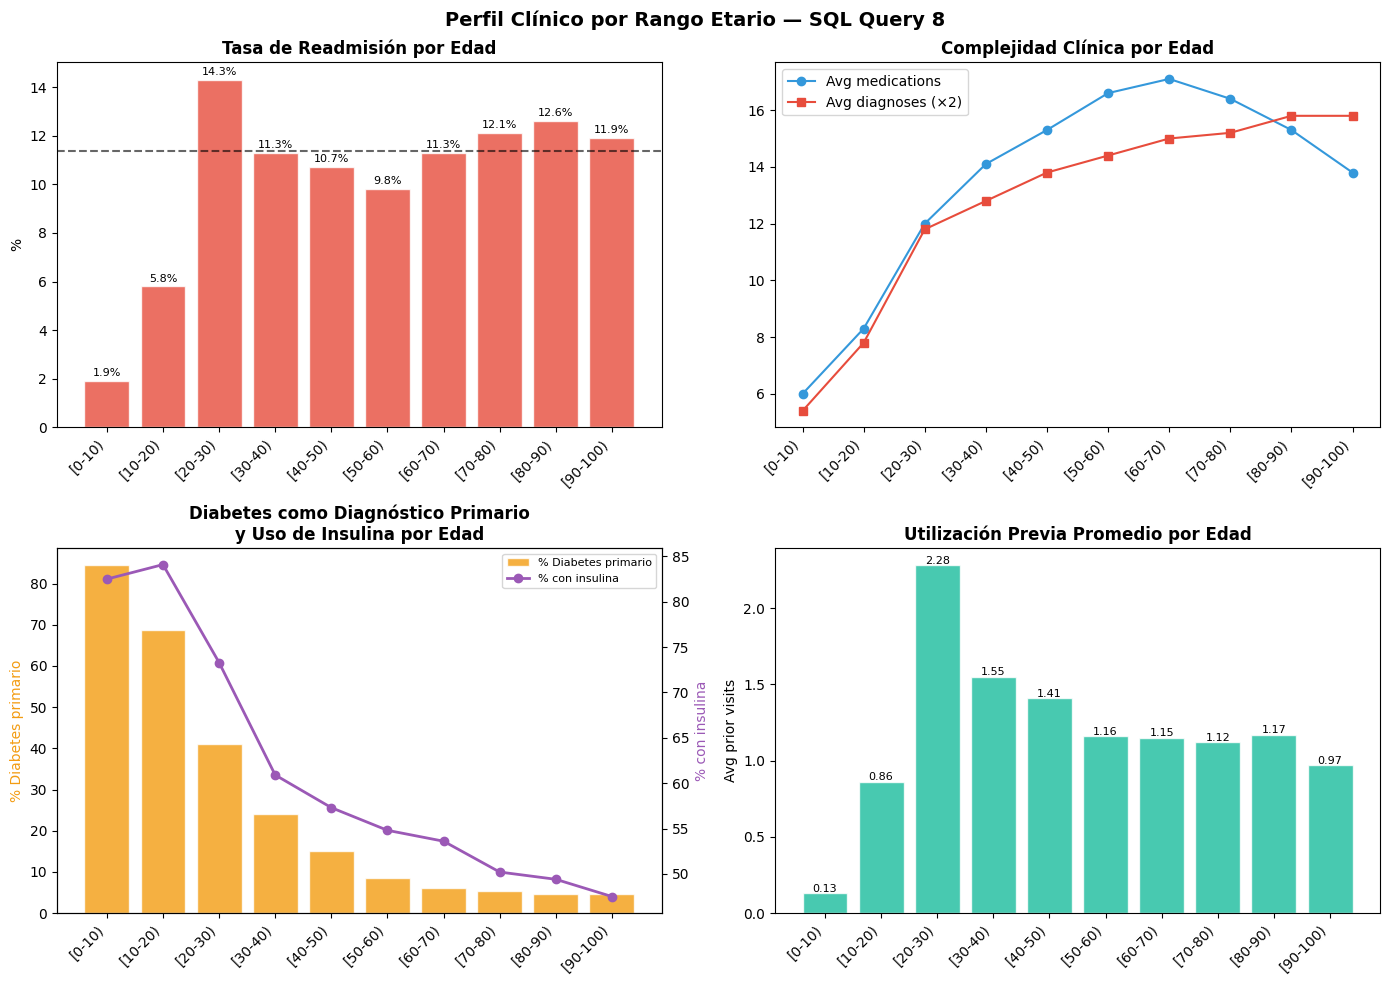

In [24]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
q8_result['age'] = pd.Categorical(q8_result['age'], categories=age_order, ordered=True)
q8_result = q8_result.sort_values('age')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Tasa de readmisión
axes[0,0].bar(range(len(q8_result)), q8_result['readmission_rate_pct'],
              color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0,0].set_xticks(range(len(q8_result)))
axes[0,0].set_xticklabels(age_order, rotation=45, ha='right')
axes[0,0].axhline(y=df_clean['readmitted_binary'].mean()*100,
                  color='black', linestyle='--', alpha=0.6)
axes[0,0].set_title('Tasa de Readmisión por Edad', fontweight='bold')
axes[0,0].set_ylabel('%')
for i, val in enumerate(q8_result['readmission_rate_pct']):
    axes[0,0].text(i, val + 0.2, f'{val}%', ha='center', fontsize=8)

# Plot 2 — Complejidad clínica
axes[0,1].plot(range(len(q8_result)), q8_result['avg_meds'],
               marker='o', color='#3498db', label='Avg medications')
axes[0,1].plot(range(len(q8_result)), q8_result['avg_diagnoses'] * 2,
               marker='s', color='#e74c3c', label='Avg diagnoses (×2)')
axes[0,1].set_xticks(range(len(q8_result)))
axes[0,1].set_xticklabels(age_order, rotation=45, ha='right')
axes[0,1].set_title('Complejidad Clínica por Edad', fontweight='bold')
axes[0,1].legend()

# Plot 3 — Diabetes como primario y uso de insulina
axes[1,0].bar(range(len(q8_result)), q8_result['pct_diabetes_primary'],
              color='#f39c12', alpha=0.8, edgecolor='white', label='% Diabetes primario')
ax_ins = axes[1,0].twinx()
ax_ins.plot(range(len(q8_result)), 100 - q8_result['pct_no_insulin'],
            marker='o', color='#9b59b6', linewidth=2, label='% con insulina')
axes[1,0].set_xticks(range(len(q8_result)))
axes[1,0].set_xticklabels(age_order, rotation=45, ha='right')
axes[1,0].set_title('Diabetes como Diagnóstico Primario\ny Uso de Insulina por Edad', 
                     fontweight='bold')
axes[1,0].set_ylabel('% Diabetes primario', color='#f39c12')
ax_ins.set_ylabel('% con insulina', color='#9b59b6')
lines1, labels1 = axes[1,0].get_legend_handles_labels()
lines2, labels2 = ax_ins.get_legend_handles_labels()
axes[1,0].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# Plot 4 — Utilización previa
axes[1,1].bar(range(len(q8_result)), q8_result['avg_prior_visits'],
              color='#1abc9c', alpha=0.8, edgecolor='white')
axes[1,1].set_xticks(range(len(q8_result)))
axes[1,1].set_xticklabels(age_order, rotation=45, ha='right')
axes[1,1].set_title('Utilización Previa Promedio por Edad', fontweight='bold')
axes[1,1].set_ylabel('Avg prior visits')
for i, val in enumerate(q8_result['avg_prior_visits']):
    axes[1,1].text(i, val + 0.01, f'{val:.2f}', ha='center', fontsize=8)

plt.suptitle('Perfil Clínico por Rango Etario — SQL Query 8', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/sql_q8_age_profile.png', dpi=150)
plt.show()

### Query 8 — Perfil Clínico por Rango Etario

**Patrón de readmisión no lineal — tres grupos distintos:**

`[0-10)` y `[10-20)`: 1.9% y 5.8% — tasas bajas, diabetes juvenil
con manejo diferente (insulina dependiente tipo 1 predominante),
84% y 69% tienen diabetes como diagnóstico primario.

`[20-30)`: 14.3% — pico anómalo. Alta utilización previa (2.28 visitas)
y 41% diabetes primaria. Posible perfil de diabetes tipo 1 descontrolada
o tipo 2 de inicio temprano con mal acceso a atención ambulatoria.
Este grupo tiene la mayor utilización previa del dataset — fragmentación
de atención y barreras de acceso son hipótesis plausibles.

`[60-90)`: 11-13% con complejidad creciente — patrón esperado de
comorbilidad acumulada. Medicamentos pico en [60-70) (17.1 avg),
luego leve descenso en mayores posiblemente por simplificación terapéutica
o deprescripción en frágiles.

**Insulina inversamente proporcional a edad:**
- [0-10): 82.5% con insulina — diabetes tipo 1 predominante
- [90-100): 47.5% con insulina — diabetes tipo 2 con manejo oral

**avg_prior_visits pico en [20-30) (2.28):**
Jóvenes con diabetes hospitalizada tienen más historia de urgencias
que adultos mayores con más comorbilidades — señal de fragmentación
de atención y posible acceso irregular al sistema ambulatorio.

**Implicación para features:**
`age_numeric` captura la tendencia general pero pierde el pico [20-30).
En feature engineering considerar flag `young_diabetic` ([20-40) con
diabetes primaria) como subgrupo de riesgo diferenciado.

In [25]:
# === GUARDAR QUERIES EN /queries ===
from pathlib import Path

queries = {
    'q1_readmission_by_inpatient_history.sql': """
SELECT 
    number_inpatient,
    COUNT(*) as n_encounters,
    SUM(readmitted_binary) as n_readmitted,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(time_in_hospital), 1) as avg_stay_days
FROM encounters
WHERE number_inpatient <= 10
GROUP BY number_inpatient
ORDER BY number_inpatient
""",
    'q2_readmission_by_stay_duration.sql': """
SELECT 
    time_in_hospital,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(num_medications), 1) as avg_medications,
    ROUND(AVG(number_diagnoses), 1) as avg_diagnoses
FROM encounters
GROUP BY time_in_hospital
ORDER BY time_in_hospital
""",
    'q3_readmission_by_diagnosis.sql': """
SELECT 
    diag_1_cat,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(time_in_hospital), 1) as avg_stay,
    ROUND(AVG(num_medications), 1) as avg_meds
FROM encounters
WHERE diag_1_cat NOT IN ('Unknown', 'External', 'Supplementary')
GROUP BY diag_1_cat
HAVING COUNT(*) > 200
ORDER BY readmission_rate_pct DESC
""",
    'q4_readmission_by_polypharmacy.sql': """
SELECT 
    CASE 
        WHEN num_medications <= 5  THEN '1-5 meds'
        WHEN num_medications <= 10 THEN '6-10 meds'
        WHEN num_medications <= 15 THEN '11-15 meds'
        WHEN num_medications <= 20 THEN '16-20 meds'
        WHEN num_medications <= 25 THEN '21-25 meds'
        ELSE '26+ meds'
    END as med_group,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(num_medications), 1) as avg_meds,
    ROUND(AVG(time_in_hospital), 1) as avg_stay
FROM encounters
GROUP BY med_group
ORDER BY avg_meds
""",
    'q5_readmission_by_discharge.sql': """
SELECT 
    discharge_disposition_id,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(time_in_hospital), 1) as avg_stay
FROM encounters
GROUP BY discharge_disposition_id
HAVING COUNT(*) > 300
ORDER BY readmission_rate_pct DESC
""",
    'q6_insulin_pharmacoclinical.sql': """
SELECT 
    insulin,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(SUM(CASE WHEN A1Cresult = '>8' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_A1C_gt8,
    ROUND(SUM(CASE WHEN was_A1C_measured = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_A1C_measured,
    ROUND(AVG(num_medications), 1) as avg_meds,
    ROUND(AVG(time_in_hospital), 1) as avg_stay,
    ROUND(AVG(number_emergency), 2) as avg_prior_emergency
FROM encounters
GROUP BY insulin
ORDER BY readmission_rate_pct DESC
""",
    'q7_high_utilization.sql': """
SELECT 
    total_prior_visits,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(num_medications), 1) as avg_meds,
    ROUND(AVG(time_in_hospital), 1) as avg_stay
FROM encounters
WHERE total_prior_visits <= 15
GROUP BY total_prior_visits
ORDER BY total_prior_visits
""",
    'q8_age_clinical_profile.sql': """
SELECT 
    age,
    COUNT(*) as n_encounters,
    ROUND(AVG(readmitted_binary) * 100, 1) as readmission_rate_pct,
    ROUND(AVG(num_medications), 1) as avg_meds,
    ROUND(AVG(number_diagnoses), 1) as avg_diagnoses,
    ROUND(AVG(total_prior_visits), 2) as avg_prior_visits,
    ROUND(AVG(time_in_hospital), 1) as avg_stay,
    ROUND(SUM(CASE WHEN diabetes_as_primary = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_diabetes_primary,
    ROUND(SUM(CASE WHEN insulin = 'No' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_no_insulin
FROM encounters
GROUP BY age
ORDER BY age
"""
}

queries_path = Path('../queries')
queries_path.mkdir(exist_ok=True)

for filename, sql in queries.items():
    with open(queries_path / filename, 'w') as f:
        f.write(sql.strip())

print(f" {len(queries)} queries guardadas en /queries")
print(f"\n Día 2 completo:")
print(f"   → features.parquet — dataset procesado")
print(f"   → 8 queries SQL con interpretación clínica")

 8 queries guardadas en /queries

 Día 2 completo:
   → features.parquet — dataset procesado
   → 8 queries SQL con interpretación clínica
